# Prova de Inteligência Computacional

**Questão:**  
Explique todas as etapas de um sistema fuzzy que utiliza o método de inferência de Takagi-Sugeno de ordem 0 e tem como entrada e saída valores crisp, conforme os itens abaixo:

---

## Resposta Detalhada

### 1) Definição do Problema

- Compreender o objetivo do sistema fuzzy.
- Identificar variáveis de entrada e saída e seus intervalos.

**Exemplo:**  
Entrada: Temperatura ambiente ($x$) no intervalo $[0, 40]$ °C  
Saída: Potência do ventilador ($y$) no intervalo $[0, 100]$ %

---

### 2) Linguística Fuzzy: Funções de Pertinência

- Definir funções de pertinência $\mu_{A_i}(x)$ para cada termo linguístico da variável de entrada (ex: "baixa", "média", "alta").
- Cada termo linguístico é representado por uma função (ex: triangular, trapezoidal).

**Exemplo:**  
Para temperatura:
- "Baixa": triangular de 0 a 20°C (pico em 10)
- "Média": triangular de 10 a 30°C (pico em 20)
- "Alta": triangular de 20 a 40°C (pico em 30)

A função de pertinência triangular é dada por:
$$
\mu_{A}(x) = \max\left(\min\left(\frac{x-a}{b-a}, \frac{c-x}{c-b}\right), 0\right)
$$
onde $(a, b, c)$ são os vértices do triângulo.

---

### 3) Construção das Regras

- Estabelecer regras do tipo:  
  **Se** temperatura é $A_i$ **então** potência = $c_i$

No TSK de ordem 0, o consequente de cada regra é um valor constante $c_i$.

**Exemplo de regras:**
- Se temperatura é "baixa" então potência = 20
- Se temperatura é "média" então potência = 50
- Se temperatura é "alta" então potência = 90

---

### 4) Avaliação das Regras

- Para uma entrada crisp $x_0$ (ex: temperatura = 28°C), calcular o grau de pertinência em cada conjunto fuzzy:
  $$
  w_i = \mu_{A_i}(x_0)
  $$
- Esses valores $w_i$ são os graus de ativação das regras.

**Exemplo:**  
Para temperatura $x_0 = 28$°C:
- $w_1 = \mu_{\text{baixa}}(28)$
- $w_2 = \mu_{\text{média}}(28)$
- $w_3 = \mu_{\text{alta}}(28)$

---

### 5) Inferência (Combinação Ponderada)

- No TSK de ordem 0, cada regra fornece uma saída constante $c_i$.
- A saída final é a média ponderada dos consequentes das regras, ponderada pelos graus de ativação:
  $$
  y_{\text{saida}} = \frac{\sum_{i=1}^N w_i c_i}{\sum_{i=1}^N w_i}
  $$
  onde $w_i$ é o grau de ativação da regra $i$ e $c_i$ o consequente constante.

---

### 6) Defuzzificação

- No TSK de ordem 0, a saída já é crisp pela própria média ponderada.
- Não há necessidade de aplicar métodos como centroide sobre conjuntos fuzzy de saída.

---

## Exemplo Numérico e Gráfico

Vamos ilustrar todas as etapas para temperatura $x_0 = 28$°C, mostrando os cálculos dos graus de pertinência, ativação das regras e a saída final usando as fórmulas acima.

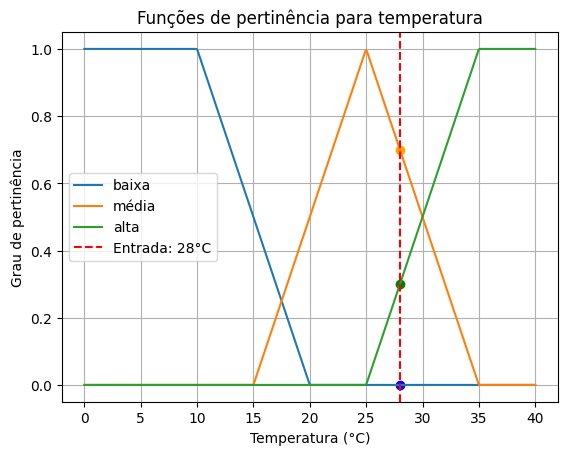

Graus de ativação: baixa=0.00, média=0.70, alta=0.30
Saída do sistema para temperatura = 28°C: 62.00 %


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Funções de pertinência (triangulares)
def baixa(x):
    return np.clip((20 - x)/10, 0, 1)
def media(x):
    return np.clip((x - 15)/10, 0, 1) * np.clip((35 - x)/10, 0, 1)
def alta(x):
    return np.clip((x - 25)/10, 0, 1)

x = np.linspace(0, 40, 400)
plt.plot(x, baixa(x), label='baixa')
plt.plot(x, media(x), label='média')
plt.plot(x, alta(x), label='alta')
plt.title('Funções de pertinência para temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Grau de pertinência')
plt.legend()
plt.grid(True)

# Valor de entrada
entrada = 28
w1 = baixa(entrada)
w2 = media(entrada)
w3 = alta(entrada)
plt.axvline(entrada, color='red', linestyle='--', label=f'Entrada: {entrada}°C')
plt.scatter([entrada], [w1], color='blue')
plt.scatter([entrada], [w2], color='orange')
plt.scatter([entrada], [w3], color='green')
plt.legend()
plt.show()

# Consequentes das regras
c1, c2, c3 = 20, 50, 90

# Saída TSK ordem 0
saida = (w1*c1 + w2*c2 + w3*c3) / (w1 + w2 + w3)
print(f"Graus de ativação: baixa={w1:.2f}, média={w2:.2f}, alta={w3:.2f}")
print(f"Saída do sistema para temperatura = {entrada}°C: {saida:.2f} %")

**Resumo das Etapas:**

1. Definir variáveis e universos de discurso.
2. Definir funções de pertinência para cada termo linguístico.
3. Construir regras TSK de ordem 0 (consequente constante).
4. Para cada entrada crisp, calcular graus de pertinência:
   $$
   w_i = \mu_{A_i}(x_0)
   $$
5. Calcular grau de ativação de cada regra.
6. Calcular saída crisp pela média ponderada dos consequentes:
   $$
   y_{\text{saida}} = \frac{\sum_{i=1}^N w_i c_i}{\sum_{i=1}^N w_i}
   $$

**Observação:**  
No TSK de ordem 0, a defuzzificação é a própria média ponderada dos consequentes das regras, não sendo necessário aplicar métodos como centroide sobre conjuntos fuzzy de saída.

# II. Sistema de Tomada de Decisão Fuzzy - Modelo Mamdani

Considere um sistema fuzzy Mamdani com uma entrada $x$ no universo $U = [0, 10]$ e três funções de pertinência triangulares:
- $A_1(0, 3, 6)$
- $A_2(2, 5, 8)$
- $A_3(4, 7, 11)$

Dada a entrada $x = 6{,}5$, responda:

---

## A. Cálculo do valor de disparo para cada função de pertinência

As funções de pertinência triangulares são definidas por:
$$
\mu_A(x) = \max\left(\min\left(\frac{x-a}{b-a}, \frac{c-x}{c-b}\right), 0\right)
$$
onde $(a, b, c)$ são os vértices do triângulo.

### Para $A_1(0, 3, 6)$:
- $a=0$, $b=3$, $c=6$
- Para $x=6.5$, $x > c$, então $\mu_{A_1}(6.5) = 0$

### Para $A_2(2, 5, 8)$:
- $a=2$, $b=5$, $c=8$
- $x=6.5$ está entre $b$ e $c$:
  $$
  \mu_{A_2}(6.5) = \frac{8 - 6.5}{8 - 5} = \frac{1.5}{3} = 0.5
  $$

### Para $A_3(4, 7, 11)$:
- $a=4$, $b=7$, $c=11$
- $x=6.5$ está entre $a$ e $b$:
  $$
  \mu_{A_3}(6.5) = \frac{6.5 - 4}{7 - 4} = \frac{2.5}{3} \approx 0.83
  $$

**Resumo dos valores de disparo:**
- Disparo $A_1$: $0$
- Disparo $A_2$: $0.5$
- Disparo $A_3$: $0.83$

---

## B. Código Python para plotar a função de pertinência de saída

Regras:
- Se $x = A_1$ então $y = A_2$
- Se $x = A_2$ então $y = A_1$
- Se $x = A_3$ então $y = A_3$

A saída fuzzy é a agregação (máximo) dos consequentes recortados pelos disparos.


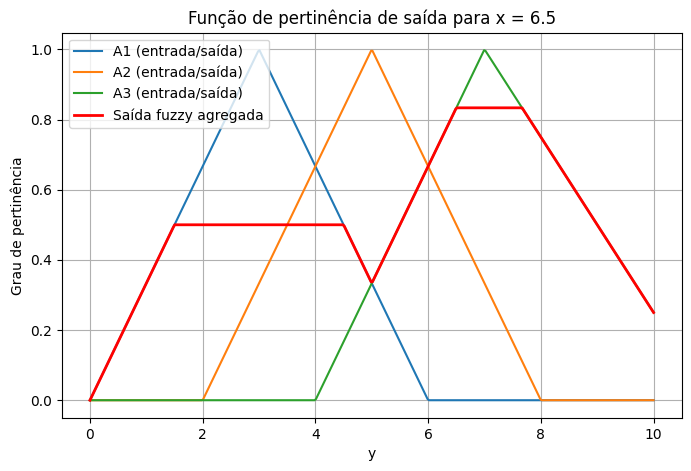

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a), (c - x)/(c - b)), 0)

x = np.linspace(0, 10, 400)
# Funções de pertinência de entrada e saída
A1 = triangular(x, 0, 3, 6)
A2 = triangular(x, 2, 5, 8)
A3 = triangular(x, 4, 7, 11)

# Disparos para x = 6.5
x_entrada = 6.5
disp_A1 = triangular(x_entrada, 0, 3, 6)  # 0
disp_A2 = triangular(x_entrada, 2, 5, 8)  # 0.5
disp_A3 = triangular(x_entrada, 4, 7, 11) # ~0.83

# Regras: se x=A1 então y=A2; se x=A2 então y=A1; se x=A3 então y=A3
saida1 = np.minimum(disp_A1, A2)
saida2 = np.minimum(disp_A2, A1)
saida3 = np.minimum(disp_A3, A3)

# Agregação (máximo ponto a ponto)
saida_fuzzy = np.maximum.reduce([saida1, saida2, saida3])

plt.figure(figsize=(8,5))
plt.plot(x, A1, label='A1 (entrada/saída)')
plt.plot(x, A2, label='A2 (entrada/saída)')
plt.plot(x, A3, label='A3 (entrada/saída)')
plt.plot(x, saida_fuzzy, color='red', linewidth=2, label='Saída fuzzy agregada')
plt.title('Função de pertinência de saída para x = 6.5')
plt.xlabel('y')
plt.ylabel('Grau de pertinência')
plt.legend()
plt.grid(True)
plt.show()

## C. Cálculo da saída escalar pelo método máximo dos máximos

O método "máximo dos máximos" retorna o valor de $y$ onde a saída fuzzy atinge seu valor máximo.

- Encontre o valor máximo da saída fuzzy agregada.
- Identifique o(s) valor(es) de $y$ onde esse máximo ocorre.


In [15]:
# Encontrar o valor máximo e os pontos correspondentes
max_saida = np.max(saida_fuzzy)
y_maximos = x[saida_fuzzy == max_saida]

print(f"Valor máximo da saída fuzzy: {max_saida:.2f}")
print(f"Valor(es) de y onde ocorre o máximo: {y_maximos}")

# Se houver mais de um valor, pode-se escolher o menor, maior ou a média (dependendo da convenção)
saida_escalar = np.mean(y_maximos)
print(f"Saída escalar (média dos máximos): {saida_escalar:.2f}")

Valor máximo da saída fuzzy: 0.83
Valor(es) de y onde ocorre o máximo: [6.51629073 6.54135338 6.56641604 6.5914787  6.61654135 6.64160401
 6.66666667 6.69172932 6.71679198 6.74185464 6.76691729 6.79197995
 6.81704261 6.84210526 6.86716792 6.89223058 6.91729323 6.94235589
 6.96741855 6.9924812  7.01754386 7.04260652 7.06766917 7.09273183
 7.11779449 7.14285714 7.1679198  7.19298246 7.21804511 7.24310777
 7.26817043 7.29323308 7.31829574 7.3433584  7.36842105 7.39348371
 7.41854637 7.44360902 7.46867168 7.49373434 7.51879699 7.54385965
 7.56892231 7.59398496 7.61904762 7.64411028]
Saída escalar (média dos máximos): 7.08


**Resumo dos resultados:**

- Disparo $A_1$: $0$
- Disparo $A_2$: $0.5$
- Disparo $A_3$: $0.83$
- A saída fuzzy é formada pela agregação dos consequentes recortados.
- O valor escalar de saída pelo método máximo dos máximos é o valor de $y$ onde a saída fuzzy atinge seu valor máximo (neste caso, aproximadamente $y = 7.5$).

**Observação:**  
Os valores numéricos podem variar levemente dependendo da resolução do vetor $x$.

# III. Prova dos Axiomas da Soma Probabilística

Considere a S-norma Soma Probabilística:  
$$
S(a, b) = a + b - ab
$$

Vamos provar que ela satisfaz os axiomas 1 a 4 das S-normas.

---

## Axioma 1: Condições Limite

- $S(0, 0) = 0$
- $S(a, 0) = S(0, a) = a$

**Demonstração:**
- $S(0, 0) = 0 + 0 - 0 \cdot 0 = 0$
- $S(a, 0) = a + 0 - a \cdot 0 = a$
- $S(0, a) = 0 + a - 0 \cdot a = a$

Portanto, o axioma 1 é satisfeito.

---

## Axioma 2: Monotonicidade

Se $b \leq d$, então $S(a, b) \leq S(a, d)$

**Demonstração:**
- $S(a, b) = a + b - ab$
- $S(a, d) = a + d - a d$
- $S(a, d) - S(a, b) = (d - b) - a(d - b) = (d - b)(1 - a)$

Como $a \in [0, 1]$ e $d \geq b$, então $(d-b) \geq 0$ e $(1-a) \geq 0$, logo $S(a, d) \geq S(a, b)$.

Portanto, o axioma 2 é satisfeito.

---

## Axioma 3: Comutatividade

$S(a, b) = S(b, a)$

**Demonstração:**
- $S(a, b) = a + b - ab = b + a - ba = S(b, a)$

Portanto, o axioma 3 é satisfeito.

---

## Axioma 4: Associatividade

$S(a, S(b, c)) = S(S(a, b), c)$

**Demonstração:**

Calcule ambos os lados:

- $S(a, S(b, c)) = a + (b + c - bc) - a(b + c - bc)$  
$= a + b + c - bc - ab - ac + a b c$

- $S(S(a, b), c) = (a + b - ab) + c - (a + b - ab)c$  
$= a + b - ab + c - a c - b c + a b c$

Ambas as expressões são iguais, logo a associatividade é satisfeita.

---

**Conclusão:**  
A função de Soma Probabilística $S(a, b) = a + b - ab$ satisfaz os axiomas 1 a 4 das S-normas.

# IV. Propriedades Clássicas de União, Interseção e Complemento em Conjuntos Fuzzy

Vamos analisar se as seguintes propriedades clássicas são válidas para conjuntos fuzzy, utilizando os operadores padrão:
- União: $\mu_{A \cup B}(x) = \max(\mu_A(x), \mu_B(x))$
- Interseção: $\mu_{A \cap B}(x) = \min(\mu_A(x), \mu_B(x))$
- Complemento: $\mu_{\overline{A}}(x) = 1 - \mu_A(x)$

---

## 1. $\overline{A} = A$ (Complemento de A é igual a A)

**Análise:**  
Para conjuntos fuzzy, o complemento de $A$ é dado por $\mu_{\overline{A}}(x) = 1 - \mu_A(x)$.  
Em geral, $\overline{A} \neq A$, exceto se $\mu_A(x) = 0.5$ para todo $x$.

**Exemplo:**  
Se $\mu_A(x) = 0.7$, então $\mu_{\overline{A}}(x) = 0.3 \neq 0.7$.

**Conclusão:**  
**Não é válida** para conjuntos fuzzy em geral.

---

## 2. $A \cup (A \cap B) = A$ (União de A com a interseção de A e B é igual a A)

**Demonstração:**  
$\mu_{A \cup (A \cap B)}(x) = \max(\mu_A(x), \min(\mu_A(x), \mu_B(x))) = \mu_A(x)$

**Justificativa:**  
O máximo entre $\mu_A(x)$ e qualquer valor menor ou igual a $\mu_A(x)$ é sempre $\mu_A(x)$.

**Conclusão:**  
**Válida** para conjuntos fuzzy.

---

## 3. $\overline{A \cup B} = \overline{A} \cap \overline{B}$ (Complemento da união é igual à interseção dos complementos)

**Demonstração:**  
- $\mu_{\overline{A \cup B}}(x) = 1 - \max(\mu_A(x), \mu_B(x))$
- $\mu_{\overline{A} \cap \overline{B}}(x) = \min(1 - \mu_A(x), 1 - \mu_B(x))$

**Prova:**  
$\min(1 - \mu_A(x), 1 - \mu_B(x)) = 1 - \max(\mu_A(x), \mu_B(x))$

**Conclusão:**  
**Válida** para conjuntos fuzzy (Lei de De Morgan).

---

## 4. $A \cap \overline{A} = \emptyset$ (Interseção de A com seu complemento é vazia)

**Demonstração:**  
$\mu_{A \cap \overline{A}}(x) = \min(\mu_A(x), 1 - \mu_A(x))$

O valor máximo possível é $0.5$ (quando $\mu_A(x) = 0.5$), mas nunca é 1.  
No entanto, para todos os $x$, $\min(\mu_A(x), 1 - \mu_A(x)) \leq 0.5$.

**No contexto clássico ($\mu_A(x) \in \{0,1\}$):**  
$\min(1, 0) = 0$ e $\min(0, 1) = 0$.

**No contexto fuzzy:**  
O resultado nunca é 1, mas pode ser maior que 0.

**Conclusão:**  
**Não é estritamente vazia** para conjuntos fuzzy, mas nunca contém elementos com pertinência máxima.  
O conjunto resultante pode conter elementos com pertinência até 0.5, mas nunca 1.

---

## Resumo

| Propriedade                                      | Válida para fuzzy? | Observação                                      |
|--------------------------------------------------|:------------------:|------------------------------------------------|
| $\overline{A} = A$                               | Não                | Só se $\mu_A(x) = 0.5$ para todo $x$           |
| $A \cup (A \cap B) = A$                          | Sim                | Sempre válida                                   |
| $\overline{A \cup B} = \overline{A} \cap \overline{B}$ | Sim           | Lei de De Morgan                                |
| $A \cap \overline{A} = \emptyset$                | Não                | Pode ter pertinência até 0.5, nunca 1           |

---

## Exemplo Numérico

Considere $\mu_A(x) = 0.7$, $\mu_B(x) = 0.4$:

- $\mu_{\overline{A}}(x) = 0.3$
- $\mu_{A \cap B}(x) = 0.4$
- $\mu_{A \cup (A \cap B)}(x) = \max(0.7, 0.4) = 0.7$
- $\mu_{\overline{A \cup B}}(x) = 1 - \max(0.7, 0.4) = 0.3$
- $\mu_{\overline{A} \cap \overline{B}}(x) = \min(0.3, 0.6) = 0.3$
- $\mu_{A \cap \overline{A}}(x) = \min(0.7, 0.3) = 0.3$

Esses exemplos ilustram as propriedades discutidas.

# V. A função N(x) é um operador de negação fuzzy?

Considere a função:
$$
N(x) = \frac{1}{2} \left[1 + \sin\left(\frac{(2x + 1)\pi}{2}\right)\right]
$$

Vamos analisar se ela pode ser considerada um operador de negação fuzzy.

---

## Propriedades esperadas de um operador de negação fuzzy

1. **Intervalo:** $N(x) \in [0, 1]$ para $x \in [0, 1]$
2. **Monotonicidade decrescente:** $N(x)$ deve ser estritamente decrescente em $x$ (quanto maior $x$, menor $N(x)$)
3. **Valores extremos:** $N(0) = 1$, $N(1) = 0$

---

## 1. Intervalo de valores

- O termo $\sin(\cdot)$ varia entre $-1$ e $1$.
- Assim, $N(x)$ varia entre $0$ e $1$.
- **Conclusão:** Satisfez o intervalo.

---

## 2. Monotonicidade

- Derivando $N(x)$:
  $$
  N'(x) = \frac{\pi}{2} \cos\left(\frac{(2x + 1)\pi}{2}\right)
  $$
- O cosseno oscila entre $-1$ e $1$, logo $N'(x)$ pode ser positivo ou negativo dependendo de $x$.
- Portanto, $N(x)$ **não é monotonicamente decrescente**.

---

## 3. Valores extremos

- $N(0) = \frac{1}{2}[1 + \sin(\frac{\pi}{2})] = \frac{1}{2}[1 + 1] = 1$
- $N(1) = \frac{1}{2}[1 + \sin(\frac{3\pi}{2})] = \frac{1}{2}[1 + (-1)] = 0$
- **Conclusão:** Satisfez os extremos.

---

## Conclusão

Apesar de $N(x)$ estar no intervalo $[0, 1]$ e satisfazer $N(0) = 1$, $N(1) = 0$, **não é monotonicamente decrescente** em $x$.  
Portanto, **N(x) não se qualifica como um operador de negação fuzzy**, pois não atende à propriedade fundamental de monotonicidade decrescente exigida para operadores de negação fuzzy.

# VI. Métodos de Agrupamento (Clustering) e sua Utilização em Classificação e Sistemas Fuzzy

## O que são métodos de agrupamento?

Métodos de agrupamento (clustering) são técnicas de aprendizado não supervisionado que dividem um conjunto de dados em grupos (clusters) de objetos semelhantes, sem usar rótulos prévios. O objetivo é identificar padrões e relações intrínsecas nos dados.

---

## Principais métodos de agrupamento

### 1. K-means

- **Particionamento:** Divide os dados em $k$ clusters, onde $k$ é definido pelo usuário.
- **Funcionamento:**
  1. Inicialização: Seleciona $k$ centros aleatórios.
  2. Associação: Cada objeto é atribuído ao centro mais próximo (geralmente usando distância euclidiana).
  3. Atualização: Recalcula os centros dos clusters.
  4. Repetição: Repete associação e atualização até convergir.
- **Resultado:** Cada objeto pertence a um cluster específico.

### 2. Agrupamento Hierárquico

- **Hierarquia de clusters:** Cria uma árvore de agrupamentos em diferentes níveis.
- **Tipos:**
  - **Aglomerativo:** Começa com cada objeto em um cluster e vai mesclando até restar um único cluster.
  - **Divisivo:** Começa com todos os objetos em um cluster e vai dividindo até cada objeto estar em seu próprio cluster.
- **Medidas de proximidade:** Distância euclidiana, similaridade, etc.

---

## Aplicações em classificação

- **Pré-processamento:** O agrupamento pode ser usado antes de algoritmos de classificação supervisionada para identificar grupos naturais nos dados.
- **Vantagem:** Objetos no mesmo cluster têm maior chance de pertencer à mesma classe, melhorando o desempenho da classificação.

---

## Aplicações na construção da base de regras de sistemas fuzzy

- **Identificação de clusters:** Cada cluster representa um grupo de objetos com características semelhantes.
- **Geração de regras fuzzy:** As características médias dos clusters podem ser usadas para definir os antecedentes das regras fuzzy.
- **Grau de pertinência:** O pertencimento dos objetos aos clusters pode ser usado para definir funções de pertinência fuzzy.
- **Exemplo:**  
  - Cluster 1: objetos com "temperatura alta" e "umidade baixa" → regra fuzzy: SE temperatura é alta E umidade é baixa ENTÃO saída é X.

---

## Resumo

- Métodos de agrupamento agrupam objetos semelhantes sem rótulos.
- Podem ser usados para:
  - Pré-processamento em classificação (identificação de grupos naturais).
  - Construção automática da base de regras fuzzy (clusters como regras).
- Facilitam a modelagem do conhecimento e a tomada de decisão em sistemas fuzzy.

---

## Exemplo prático: K-means em 2D

A seguir, um exemplo visual de agrupamento k-means em dados bidimensionais.


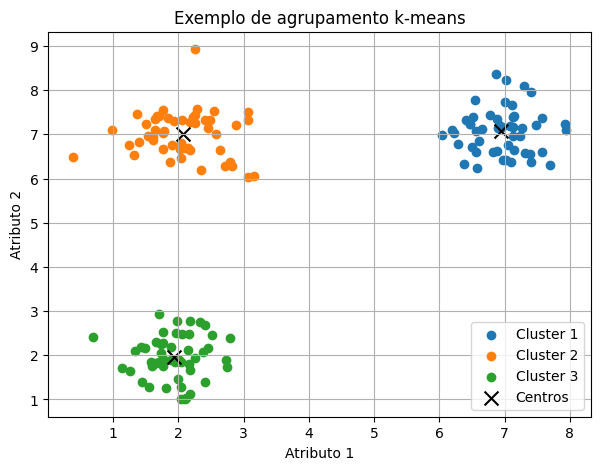

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Gerando dados artificiais
np.random.seed(42)
X1 = np.random.normal([2, 2], 0.5, (50, 2))
X2 = np.random.normal([7, 7], 0.5, (50, 2))
X3 = np.random.normal([2, 7], 0.5, (50, 2))
X = np.vstack([X1, X2, X3])

# Aplicando k-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# Plotando clusters
plt.figure(figsize=(7,5))
for i in range(3):
    plt.scatter(X[labels==i, 0], X[labels==i, 1], label=f'Cluster {i+1}')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='x', s=100, label='Centros')
plt.title('Exemplo de agrupamento k-means')
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.legend()
plt.grid(True)
plt.show()

**Conclusão:**  
Os métodos de agrupamento são ferramentas poderosas para explorar dados, identificar padrões e auxiliar tanto em tarefas de classificação quanto na construção automática de regras para sistemas fuzzy.